# First Break Picking — Training Demo (adapted from hardpicks)

Adapted from `hardpicks/examples/local/fbp_train_with_api.ipynb` for this repo.

- Trains hardpicks **FBPUNet** from either **NPZ** (fast I/O) or live **HDF5**
- Set `DATA_BACKEND` in the knobs cell: `"npz"` or `"hdf5"`
- After training, prints a **full train/validation summary** (tables + plots)

**Requirements:** `hardpicks` + `torch` + `pytorch-lightning` (see `setup_lightning.sh` / `requirements-lightning.txt`).

A GPU is strongly recommended.


In [1]:
from __future__ import annotations

import functools
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
import torch.utils.data
from IPython.display import display

# repo root on sys.path when the notebook cwd is examples/local
REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hardpicks
from seismic_utils.hardpicks_pl_compat import ensure_hardpicks_lightning_compat

# hardpicks targets PL 1.x; Lightning AI images often ship PL 2.x
print("PL compat:", ensure_hardpicks_lightning_compat())

import hardpicks.data.fbp.data_module as fbp_data_module
import hardpicks.models.fbp.unet as fbp_unet
import hardpicks.models.fbp.utils as model_utils
from seismic_utils.dataset import DEFAULT_DATA_DIR
from seismic_utils.hardpicks_bridge import hardpicks_available, resolve_hardpicks_site_info
from seismic_utils.npz_parser import create_npz_parser

assert hardpicks_available(), "hardpicks (+ torch) required — run setup_lightning.sh / install requirements"
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(), "| pl", pl.__version__)
print("hardpicks", hardpicks.__file__)
print("DATA_DIR", DEFAULT_DATA_DIR)

/home/mika/anaconda3/envs/seismic_activity/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mika/anaconda3/envs/seismic_activity/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PL compat: pl-2.4.0-patched-v2
torch 2.4.1+cu121 | cuda True | pl 2.4.0
hardpicks /home/mika/dev/seismic_activity/src/hardpicks/hardpicks/__init__.py
DATA_DIR /home/mika/data/seismic_activity


In [2]:
# ---------------- user knobs ----------------
SITE_NAME = "Brunswick"  # Brunswick | Halfmile | Lalor | Sudbury
# "npz" = fast per-gather files under NPZ_ROOT (recommended after export)
# "hdf5" = live hardpicks HDF5 parser (slower I/O)
DATA_BACKEND = os.environ.get("FBP_DATA_BACKEND", "npz")  # npz | hdf5
DATA_DIR = Path(os.environ.get("SEISMIC_DATA_DIR", DEFAULT_DATA_DIR))
NPZ_ROOT = Path(os.environ.get("SEISMIC_NPZ_DIR", DATA_DIR / "npz"))
MAX_EPOCHS = int(os.environ.get("FBP_MAX_EPOCHS", "5"))
BATCH_SIZE = int(os.environ.get("FBP_BATCH_SIZE", "4"))
NUM_WORKERS = int(os.environ.get("FBP_NUM_WORKERS", "2"))
EVAL_RATIO = 0.15
SEGMENTATION_CLASS_COUNT = 1  # binary: first-break vs background

OUTPUT_ROOT = (REPO_ROOT / "output" / f"train_{SITE_NAME.lower()}").resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Experiment dir:", OUTPUT_ROOT)
print("DATA_BACKEND:", DATA_BACKEND, "| NPZ_ROOT:", NPZ_ROOT)

logging.getLogger().setLevel(logging.INFO)

tbx_dir = OUTPUT_ROOT / "tensorboard"
csv_dir = OUTPUT_ROOT / "csv_logs"
tbx_dir.mkdir(exist_ok=True)
csv_dir.mkdir(exist_ok=True)

tbx_logger = pl.loggers.TensorBoardLogger(save_dir=str(tbx_dir), name="default", default_hp_metric=False)
csv_logger = pl.loggers.CSVLogger(save_dir=str(csv_dir), name="metrics")
print("TensorBoard:", f"tensorboard --logdir {tbx_dir}")

Experiment dir: /home/mika/dev/seismic_activity/output/train_brunswick
DATA_BACKEND: npz | NPZ_ROOT: /home/mika/data/seismic_activity/npz
TensorBoard: tensorboard --logdir /home/mika/dev/seismic_activity/output/train_brunswick/tensorboard


## Data loading

Choose the source in the knobs cell (`DATA_BACKEND`):

- **`npz`** — `create_npz_parser` reads `NPZ_ROOT/<SITE_NAME>/` (export first with `python -m seismic_utils.export_npz ... -o $NPZ_ROOT`).
- **`hdf5`** — live hardpicks `FBPDataModule.create_parser` on the site HDF5 (cleaning / reject list).


In [ ]:
train_augmentations = [
    {
        "type": "crop",
        "params": {
            "low_sample_count": 512,
            "high_sample_count": 1024,
            "max_crop_fraction": 0.333,
        },
    },
    {"type": "flip"},
]

common_site_params = {
    "normalize_samples": True,
    "segm_first_break_buffer": 0,
}

backend = DATA_BACKEND.strip().lower()
print(f"DATA_BACKEND={backend!r}")

if backend == "npz":
    print(f"Using NPZ parser at {NPZ_ROOT / SITE_NAME}")
    train_parser = create_npz_parser(
        SITE_NAME,
        npz_root=NPZ_ROOT,
        prefix="train",
        site_params={
            **common_site_params,
            "augmentations": train_augmentations,
            "subset": {"eval_ratio": EVAL_RATIO, "use_eval_split": False},
        },
        segm_class_count=SEGMENTATION_CLASS_COUNT,
    )
    valid_parser = create_npz_parser(
        SITE_NAME,
        npz_root=NPZ_ROOT,
        prefix="valid",
        site_params={
            **common_site_params,
            "subset": {"eval_ratio": EVAL_RATIO, "use_eval_split": True},
        },
        segm_class_count=SEGMENTATION_CLASS_COUNT,
    )
elif backend == "hdf5":
    site_info = resolve_hardpicks_site_info(SITE_NAME, data_dir=DATA_DIR)
    print("Using HDF5 parser")
    for k, v in site_info.items():
        print(f"  {k}: {v}")

    rejected = Path(hardpicks.FBP_BAD_GATHERS_DIR) / "bad-gather-ids_combined.yaml"
    if not rejected.is_file():
        rejected = None
        print("WARNING: bad-gather YAML not found; continuing without reject list")

    hdf5_site_params = {
        **common_site_params,
        "rejected_gather_yaml_path": str(rejected) if rejected else None,
        "use_cache": False,
    }
    generic_site_params = dict(
        convert_to_fp16=True,
        convert_to_int16=True,
        preload_trace_data=False,
        cache_trace_metadata=True,
        provide_offset_dists=True,
    )
    train_parser = fbp_data_module.FBPDataModule.create_parser(
        site_info=site_info,
        site_params={
            **hdf5_site_params,
            "augmentations": train_augmentations,
            "subset": {"eval_ratio": EVAL_RATIO, "use_eval_split": False},
        },
        prefix="train",
        dataset_hyper_params=generic_site_params,
        segm_class_count=SEGMENTATION_CLASS_COUNT,
    )
    valid_parser = fbp_data_module.FBPDataModule.create_parser(
        site_info=site_info,
        site_params={
            **hdf5_site_params,
            "subset": {"eval_ratio": EVAL_RATIO, "use_eval_split": True},
        },
        prefix="valid",
        dataset_hyper_params=generic_site_params,
        segm_class_count=SEGMENTATION_CLASS_COUNT,
    )
else:
    raise ValueError(f"Unknown DATA_BACKEND={DATA_BACKEND!r}; use 'npz' or 'hdf5'")

print(f"Train gathers: {len(train_parser)} | Valid gathers: {len(valid_parser)}")

train_ids = [train_parser.get_meta_gather(i)["gather_id"] for i in range(len(train_parser))]
valid_ids = [valid_parser.get_meta_gather(i)["gather_id"] for i in range(len(valid_parser))]
assert len(np.intersect1d(train_ids, valid_ids)) == 0
print("Train/valid gather IDs are disjoint.")


In [4]:
collate_fn = functools.partial(
    fbp_data_module.fbp_batch_collate,
    pad_to_nearest_pow2=True,
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_parser,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)
valid_loader = torch.utils.data.DataLoader(
    dataset=valid_parser,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)
print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

Train batches: 3355 | Valid batches: 1260


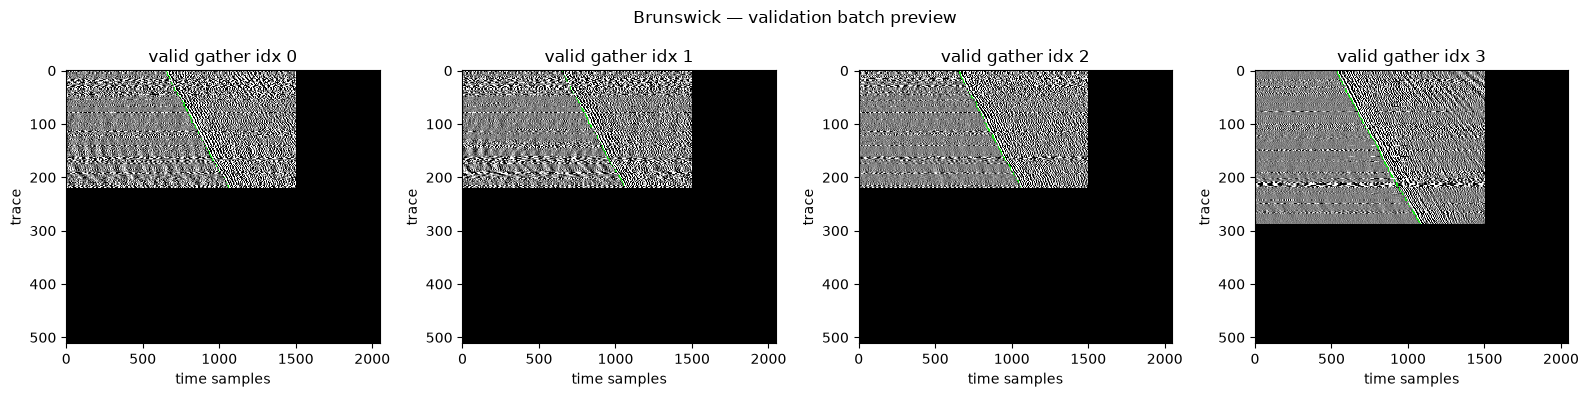

Saved /home/mika/dev/seismic_activity/output/train_brunswick/valid_batch_preview.png


In [5]:
# Preview one validation minibatch (GT picks in green)
minibatch = next(iter(valid_loader))
n_show = min(4, minibatch["samples"].shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    img = model_utils.generate_pred_image(
        batch=minibatch,
        raw_preds=None,
        batch_gather_idx=i,
        segm_class_count=SEGMENTATION_CLASS_COUNT,
        segm_first_break_prob_threshold=0.0,
        draw_prior=False,
        draw_prob_heatmap=False,
    )
    axes[i].imshow(img, interpolation="none", aspect="auto")
    axes[i].set_title(f"valid gather idx {i}")
    axes[i].set_xlabel("time samples")
    axes[i].set_ylabel("trace")
fig.suptitle(f"{SITE_NAME} — validation batch preview")
fig.tight_layout()
preview_path = OUTPUT_ROOT / "valid_batch_preview.png"
fig.savefig(preview_path, dpi=120)
plt.show()
print("Saved", preview_path)

## Model

In [6]:
model_config = {
    "unet_encoder_type": "resnet18",
    "unet_decoder_type": "vanilla",
    "encoder_block_count": 5,
    "mid_block_channels": 0,
    "decoder_block_channels": "[256, 128, 64, 32, 16]",
    "decoder_attention_type": None,
    "segm_class_count": SEGMENTATION_CLASS_COUNT,
    "use_dist_offsets": True,
    "use_first_break_prior": False,
    "coordconv": False,
    "optimizer_type": "Adam",
    "optimizer_params": {"lr": 0.002136, "weight_decay": 1e-6},
    "scheduler_type": "StepLR",
    "scheduler_params": {"step_size": 10, "gamma": 0.1},
    "update_scheduler_at_epochs": True,
    "loss_type": "crossentropy",
    "loss_params": {},
    "use_full_metrics_during_training": False,
    "eval_type": "FBPEvaluator",
    "segm_first_break_prob_threshold": 0.0,
    "eval_metrics": [
        {"metric_type": "HitRate", "metric_params": {"buffer_size_px": 1}},
        {"metric_type": "HitRate", "metric_params": {"buffer_size_px": 3}},
        {"metric_type": "HitRate", "metric_params": {"buffer_size_px": 5}},
        {"metric_type": "MeanBiasError"},
        {"metric_type": "MeanAbsoluteError"},
    ],
    "gathers_to_display": 0,
    "use_checkpointing": False,
    "max_epochs": MAX_EPOCHS,
}

model = fbp_unet.FBPUNet(model_config)
setattr(model, "_tbx_logger", tbx_logger)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FBPUNet ready: {n_params / 1e6:.2f}M trainable parameters")

FBPUNet ready: 14.24M trainable parameters


## Training

In [7]:
monitor_metric = "valid/HitRate1px"
checkpoint_cb = pl.callbacks.ModelCheckpoint(
    dirpath=str(OUTPUT_ROOT),
    filename="best-{epoch:03d}-{step:06d}",
    monitor=monitor_metric,
    mode="max",
    save_top_k=1,
)

trainer_kwargs = dict(
    logger=[tbx_logger, csv_logger],
    callbacks=[checkpoint_cb],
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

_pl_major = int(str(pl.__version__).split(".", 1)[0])
if _pl_major >= 2:
    trainer = pl.Trainer(
        **trainer_kwargs,
        accelerator="auto",
        devices=1 if torch.cuda.is_available() else "auto",
    )
else:
    trainer = pl.Trainer(
        **trainer_kwargs,
        gpus=int(bool(torch.cuda.device_count())),
    )

print("Device:", "GPU" if torch.cuda.is_available() else "CPU")
print("pytorch-lightning", pl.__version__)

# Fail here with the real error (collate / shapes) instead of inside Trainer.
_batch = next(iter(train_loader))
print("batch keys:", sorted(_batch.keys()))
print("samples", tuple(_batch["samples"].shape), _batch["samples"].dtype)

print(f"Training for {MAX_EPOCHS} epochs…")
# Positional args work on both PL 1.x and 2.x (2nd arg = train loader, 3rd = val loaders).
trainer.fit(model, train_loader, valid_loader)

best_path = Path(checkpoint_cb.best_model_path).resolve() if checkpoint_cb.best_model_path else None
print("Best checkpoint:", best_path)
print("Best score:", checkpoint_cb.best_model_score)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Device: GPU
pytorch-lightning 2.4.0


batch keys: ['bad_first_breaks_mask', 'batch_size', 'dead_rec_mask', 'first_break_labels', 'first_break_timestamps', 'gather_id', 'gather_trace_ids', 'offset_distances', 'origin', 'rec_coords', 'rec_ids', 'rec_line_id', 'sample_count', 'sample_rate_ms', 'samples', 'segmentation_mask', 'shot_coords', 'shot_id', 'trace_count']
samples (4, 512, 1024) torch.float32
Training for 5 epochs…


You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/mika/anaconda3/envs/seismic_activity/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/mika/dev/seismic_activity/output/train_brunswick exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | loss_fn | CrossEntropyLoss | 0      | train
1 | encoder | ResNetEncoder    | 11.2 M | train
2 | decoder | Basic2DDecoder   | 3.1 M  | train
-----------------------------------------------------
14.2 M    Trainable params
0         Non-trainable param

Epoch 2:   2%|▏         | 52/3355 [00:12<13:42,  4.02it/s, v_num=7, train/loss=0.00078]   


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## Training / validation summary

Loads CSV metrics logged during `fit`, prints tables, and plots train vs validation curves.

In [ ]:
def _find_metrics_csv(csv_root: Path) -> Path:
    candidates = sorted(csv_root.rglob("metrics.csv"))
    if not candidates:
        raise FileNotFoundError(f"No metrics.csv under {csv_root}")
    return candidates[-1]


def _epoch_table(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse step-wise CSVLogger rows into one row per epoch."""
    if "epoch" not in df.columns:
        raise ValueError("metrics.csv has no epoch column")
    rows = []
    for epoch, g in df.groupby("epoch", sort=True):
        row = {"epoch": int(epoch)}
        for col in g.columns:
            if col in {"epoch", "step"}:
                continue
            vals = g[col].dropna()
            if len(vals):
                row[col] = float(vals.iloc[-1])
        rows.append(row)
    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


metrics_csv = _find_metrics_csv(csv_dir)
raw_metrics = pd.read_csv(metrics_csv)
epoch_df = _epoch_table(raw_metrics)
epoch_csv = OUTPUT_ROOT / "epoch_metrics.csv"
epoch_df.to_csv(epoch_csv, index=False)

print("=" * 72)
print(f"TRAINING SUMMARY — site={SITE_NAME}  epochs={MAX_EPOCHS}")
print("=" * 72)
print(f"Output dir     : {OUTPUT_ROOT}")
print(f"Train gathers  : {len(train_parser)}")
print(f"Valid gathers  : {len(valid_parser)}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Best checkpoint: {best_path}")
print(f"Best {monitor_metric}: {checkpoint_cb.best_model_score}")
print(f"Metrics CSV    : {metrics_csv}")
print()

display_cols = [c for c in epoch_df.columns if c == "epoch" or c.startswith("train") or c.startswith("valid")]
summary_table = epoch_df[display_cols].copy()
print("Per-epoch metrics:")
display(summary_table.round(4))

if len(epoch_df):
    last = epoch_df.iloc[-1]
    print("\nFinal epoch:")
    for c in display_cols:
        if c == "epoch":
            continue
        if pd.notna(last.get(c)):
            print(f"  {c:30s} {last[c]:.6g}")

    # Best validation rows for key metrics
    print("\nBest validation values across epochs:")
    for col in [c for c in epoch_df.columns if c.startswith("valid/")]:
        series = epoch_df[col].dropna()
        if series.empty:
            continue
        # hit-rate-like: higher better; error-like: lower better
        lower_better = any(k in col.lower() for k in ("error", "loss", "mae", "mse", "rmse", "bias"))
        if "bias" in col.lower() and "abs" not in col.lower():
            # MeanBiasError: prefer closest to 0
            idx = series.abs().idxmin()
            tag = "closest-to-0"
        elif lower_better:
            idx = series.idxmin()
            tag = "min"
        else:
            idx = series.idxmax()
            tag = "max"
        ep = int(epoch_df.loc[idx, "epoch"])
        print(f"  {col:30s} {series.loc[idx]:.6g}  ({tag} @ epoch {ep})")

In [ ]:
# Plots: loss + key validation metrics
plot_specs = []
train_loss_cols = [c for c in epoch_df.columns if "loss" in c.lower() and c.startswith("train")]
valid_loss_cols = [c for c in epoch_df.columns if "loss" in c.lower() and c.startswith("valid")]
if train_loss_cols or valid_loss_cols:
    plot_specs.append(("Loss", train_loss_cols + valid_loss_cols))

hit_cols = [c for c in epoch_df.columns if "HitRate" in c]
if hit_cols:
    plot_specs.append(("Hit rate", hit_cols))

err_cols = [c for c in epoch_df.columns if any(k in c for k in ("MeanAbsoluteError", "MeanBiasError", "MAE", "MBE"))]
if err_cols:
    plot_specs.append(("Pick error", err_cols))

# fallback: any train_* / valid_* numeric columns
if not plot_specs:
    cols = [c for c in epoch_df.columns if c.startswith(("train", "valid"))]
    plot_specs.append(("Metrics", cols))

n = len(plot_specs)
fig, axes = plt.subplots(n, 1, figsize=(10, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, (title, cols) in zip(axes, plot_specs):
    for col in cols:
        s = epoch_df[["epoch", col]].dropna()
        if s.empty:
            continue
        ax.plot(s["epoch"], s[col], marker="o", label=col)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Epoch")
fig.suptitle(f"{SITE_NAME} — training / validation curves", y=1.01)
fig.tight_layout()
curves_path = OUTPUT_ROOT / "train_valid_curves.png"
fig.savefig(curves_path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", curves_path)
print("Saved", epoch_csv)

In [ ]:
# Re-run validation with the best checkpoint (if available) for a clean summary dict
if best_path and best_path.is_file():
    best_model = fbp_unet.FBPUNet.load_from_checkpoint(str(best_path))
    setattr(best_model, "_tbx_logger", tbx_logger)
    try:
        val_out = trainer.validate(best_model, dataloaders=valid_loader)
    except TypeError:
        val_out = trainer.validate(best_model, val_dataloaders=valid_loader)
    print("\nValidation with best checkpoint:")
    if isinstance(val_out, list) and val_out:
        for k, v in sorted(val_out[0].items()):
            print(f"  {k:30s} {v}")
else:
    print("No best checkpoint on disk; skipped final validate().")

print("\nDone.")